In [4]:
import pandas as pd
import numpy as np
from google.colab import files

In [5]:
upload = files.upload()

#Primary key and check info

In [6]:
df = pd.read_csv("food_delivery_raw.csv")

In [7]:
df.head()

,order_id,customer_id,order_datetime,city,restaurant_category,restaurant_name,order_channel,payment_method,subtotal,delivery_fee,discount_amount,promo_code,distance_km,prep_time_min,delivery_time_min,weather,traffic_level,courier_vehicle,order_status,customer_rating
0,ORD0000001,C00187,2025-03-10 21:18:55,Chonburi,Fast Food,Chicken Box,Mobile App,PromptPay,261.57,48.49,13.08,WEEKEND,6.09,14,42,Clear,Medium,Motorbike,Delivered,4.0
1,ORD0000002,C01553,2026-03-06 11:59:57,Bangkok,Thai,Siam Dish,Mobile App,E-Wallet,241.30,52.45,20.00,LUNCH20,4.99,9,49,Cloudy,High,Car,Delivered,4.0
2,ORD0000003,C02262,11/07/2025 21:01,Chiang Mai,Korean,Han River Kitchen,Mobile App,E-Wallet,134.59,27.87,0.00,NaN,2.34,24,30,Clear,Medium,Motorbike,Delivered,5.0
3,ORD0000004,C01476,2025-01-24 11:28:21,Chiang Mai,Fast Food,QuickBite,Mobile App,Cash,200.57,41.50,0.00,NaN,3.00,19,30,Clear,High,Motorbike,Delivered,4.0
4,ORD0000005,C01026,2025-12-28 21:21:40,Bangkok,Thai,Siam Dish,Website,E-Wallet,360.49,51.08,0.00,NaN,5.65,21,48,Clear,High,Motorbike,Delivered,5.0


In [8]:
df.shape

(8025, 20)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8025 entries, 0 to 8024
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             8025 non-null   object 
 1   customer_id          8025 non-null   object 
 2   order_datetime       8025 non-null   object 
 3   city                 7984 non-null   object 
 4   restaurant_category  7990 non-null   object 
 5   restaurant_name      8025 non-null   object 
 6   order_channel        8025 non-null   object 
 7   payment_method       7980 non-null   object 
 8   subtotal             8025 non-null   float64
 9   delivery_fee         8025 non-null   float64
 10  discount_amount      8025 non-null   float64
 11  promo_code           4196 non-null   object 
 12  distance_km          8025 non-null   float64
 13  prep_time_min        8025 non-null   int64  
 14  delivery_time_min    8025 non-null   int64  
 15  weather              7990 non-null   o

In [10]:
df["order_id"].nunique()

8000

In [11]:
len(df)

8025

In [12]:
df["order_id"].duplicated().sum()

np.int64(25)

# check missing value

In [13]:
df.isna().sum()

,0
order_id,0
customer_id,0
order_datetime,0
city,41
restaurant_category,35
restaurant_name,0
order_channel,0
payment_method,45
subtotal,0
delivery_fee,0


In [14]:
missing = pd.DataFrame({"missing_count" : df.isna().sum(),
                        "missing_pct": df.isna().mean()*100}) #pct = missing = ... %
missing.sort_values("missing_pct", ascending =  False)

,missing_count,missing_pct
promo_code,3829,47.713396
customer_rating,696,8.672897
payment_method,45,0.560748
city,41,0.510903
traffic_level,40,0.498442
restaurant_category,35,0.436137
weather,35,0.436137
order_id,0,0.000000
order_datetime,0,0.000000
customer_id,0,0.000000


In [15]:
df["promo_code"].value_counts(dropna=False) #NaN

,count
promo_code,
NaN,3829
PAYDAY,799
FREESHIP,641
WELCOME50,634
WEEKEND,611
SONGKRAN,521
LUNCH20,501
NEWYEAR,489


In [16]:
df["customer_rating"].value_counts(dropna=False) #NaN

,count
customer_rating,
5.0,5718
4.0,1503
NaN,696
3.0,90
0.0,6
6.0,5
2.0,3
7.0,2
-1.0,2


In [17]:
df["payment_method"].value_counts(dropna=False) #dif front

,count
payment_method,
PromptPay,2353
E-Wallet,2130
Credit Card,1811
Cash,975
Debit Card,613
NaN,45
Prompt Pay,25
Cash,21
credit card,18


In [18]:
df["city"].value_counts(dropna=False) #NaN and dif front

,count
city,
Bangkok,3302
Chiang Mai,1240
Phuket,934
Chonburi,849
Nakhon Ratchasima,791
Khon Kaen,758
NaN,41
chiang mai,20
Chiangmai,18


In [19]:
df["traffic_level"].value_counts(dropna=False) #NaN

,count
traffic_level,
Medium,3521
High,2323
Low,1614
Severe,527
NaN,40


In [20]:
df["restaurant_category"].value_counts(dropna=False) #NaN

,count
restaurant_category,
Thai,1735
Fast Food,1475
Japanese,1116
Cafe & Bakery,1036
Chinese,821
Korean,731
Healthy,555
Dessert,521
NaN,35


In [21]:
df["weather"].value_counts(dropna=False) #NaN

,count
weather,
Clear,4394
Cloudy,1983
Rain,1350
Heavy Rain,263
NaN,35


#DATA CLEANING



In [22]:
clean_df = df.copy()

## Clean Categorical

In [23]:
categoriecal_cols = [
    "promo_code",
    "customer_rating",
    "traffic_level",
    "restaurant_category",
    "weather",
]

clean_df[categoriecal_cols].head(10)

,promo_code,customer_rating,traffic_level,restaurant_category,weather
0,WEEKEND,4.0,Medium,Fast Food,Clear
1,LUNCH20,4.0,High,Thai,Cloudy
2,NaN,5.0,Medium,Korean,Clear
3,NaN,4.0,High,Fast Food,Clear
4,NaN,5.0,High,Thai,Clear
5,WELCOME50,5.0,Medium,Chinese,Clear
6,NaN,4.0,Medium,Healthy,Clear
7,WEEKEND,NaN,Medium,Japanese,Clear
8,NaN,NaN,Low,Korean,Cloudy
9,NEWYEAR,4.0,Severe,Thai,Clear


###promotion

In [24]:
promo_missing = clean_df["promo_code"].isna()

clean_df.loc[
    promo_missing &
    (
        (clean_df["discount_amount"] > 0) |
        (clean_df["delivery_fee"] == 0)
    ),
    "promo_code"
] = "Unknown Promo"

clean_df["promo_code"] = clean_df["promo_code"].fillna("No Promo")

In [25]:
clean_df["promo_code"].value_counts()

,count
promo_code,
No Promo,3798
PAYDAY,799
FREESHIP,641
WELCOME50,634
WEEKEND,611
SONGKRAN,521
LUNCH20,501
NEWYEAR,489
Unknown Promo,31


In [26]:
clean_df["promo_used"] = clean_df["promo_code"].apply(
    lambda x: "Promo" if x != "No Promo" else "No Promo"
)

clean_df["promo_used"].value_counts()

,count
promo_used,
Promo,4227
No Promo,3798


###customer rating

In [27]:
# เปลี่ยน str เป็น numberic ก่อน

clean_df["customer_rating"] = pd.to_numeric(
    clean_df["customer_rating"],
    errors="coerce"
)

In [28]:
clean_df.loc[
    (clean_df["customer_rating"] <= 0) |
    (clean_df["customer_rating"] > 5),
    "customer_rating"
] = pd.NA

In [29]:
clean_df["customer_rating"].value_counts(dropna=False)

,count
customer_rating,
5.0,5718
4.0,1503
NaN,711
3.0,90
2.0,3


In [30]:
clean_df["customer_rating"].dtype

dtype('float64')

###payment method

In [31]:
clean_df["payment_method"] = df["payment_method"].fillna("Unknown")

In [32]:
payment_map = {
    "Prompt Pay": "PromptPay",
    "promptpay": "PromptPay",
    "Cash": "Cash",
    "Ewallet": "E-Wallet",
    "CreditCard": "Credit Card",
    "credit card": "Credit Card"
}

clean_df["payment_method"] = (
    clean_df["payment_method"]
    .str.strip()
    .replace(payment_map)
)

clean_df["payment_method"].value_counts()

,count
payment_method,
PromptPay,2388
E-Wallet,2143
Credit Card,1840
Cash,996
Debit Card,613
Unknown,45


###city

In [33]:
city_map = {
    "bangkok": "Bangkok",
    "BKK": "Bangkok",

    "Chiangmai": "Chiang Mai",
    "chiang mai": "Chiang Mai",

    "KHON KAEN": "Khon Kaen",

    "Chon Buri": "Chonburi"
}

clean_df["city"] = (
    clean_df["city"]
    .str.strip()
    .replace(city_map)
)


clean_df["city"] = clean_df["city"].fillna("Unknown")

clean_df["city"].value_counts(dropna=False)

,count
city,
Bangkok,3331
Chiang Mai,1278
Phuket,946
Chonburi,866
Nakhon Ratchasima,791
Khon Kaen,772
Unknown,41


###traffic level

In [34]:
clean_df["traffic_level"] = df["traffic_level"].fillna("Unknown")

In [35]:
clean_df["traffic_level"].value_counts(dropna=False)

,count
traffic_level,
Medium,3521
High,2323
Low,1614
Severe,527
Unknown,40


###restaurant category

In [36]:
clean_df["restaurant_category"] = df["restaurant_category"].fillna("Unknown")

In [37]:
clean_df["restaurant_category"].value_counts(dropna=False)

,count
restaurant_category,
Thai,1735
Fast Food,1475
Japanese,1116
Cafe & Bakery,1036
Chinese,821
Korean,731
Healthy,555
Dessert,521
Unknown,35


###weather

In [38]:
clean_df["weather"] = df["weather"].fillna("Unknown")

In [39]:
clean_df["weather"].value_counts(dropna=False)

,count
weather,
Clear,4394
Cloudy,1983
Rain,1350
Heavy Rain,263
Unknown,35


###order channel

In [40]:
channel_map = {
    "mobile app": "Mobile App",
    "MobileApp": "Mobile App",
    "APP": "Mobile App",
    "website": "Website",
    "Web": "Website"
}

clean_df["order_channel"] = (
    clean_df["order_channel"]
    .str.strip()
    .replace(channel_map)
)

clean_df["order_channel"].value_counts(dropna=False)

,count
order_channel,
Mobile App,6988
Website,1037


###restaurant name

In [41]:
clean_df["restaurant_name"] = clean_df["restaurant_name"].str.strip()
clean_df["restaurant_name"].value_counts(dropna=False)

,count
restaurant_name,
Baan Thai Kitchen,591
Siam Dish,583
Thai Basil House,567
QuickBite,509
Chicken Box,505
Burger Hub,466
Tokyo Bowl,382
Bean & Bun,377
Nippon Kitchen,372


#####check

In [42]:
clean_df[ [
    "promo_code",
    "customer_rating",
    "traffic_level",
    "restaurant_category",
    "weather",
]
]

,promo_code,customer_rating,traffic_level,restaurant_category,weather
0,WEEKEND,4.0,Medium,Fast Food,Clear
1,LUNCH20,4.0,High,Thai,Cloudy
2,No Promo,5.0,Medium,Korean,Clear
3,No Promo,4.0,High,Fast Food,Clear
4,No Promo,5.0,High,Thai,Clear
...,...,...,...,...,...
8020,No Promo,5.0,Medium,Healthy,Clear
8021,No Promo,5.0,High,Cafe & Bakery,Cloudy
8022,No Promo,5.0,Medium,Dessert,Clear
8023,WEEKEND,5.0,Medium,Fast Food,Clear


## Clean Numberic
** เช็คทั้งค่า min max ที่ผิดปกติ

In [43]:
numeric_cols = [
    "subtotal",
    "delivery_fee",
    "discount_amount",
    "distance_km",
    "prep_time_min",
    "delivery_time_min",
    "customer_rating"
]

clean_df[numeric_cols].describe()

,subtotal,delivery_fee,discount_amount,distance_km,prep_time_min,delivery_time_min,customer_rating
count,8025.000000,8025.000000,8025.000000,8025.000000,8025.000000,8025.000000,7314.000000
mean,313.154318,35.198533,12.364090,3.629163,19.147664,34.484486,4.768663
std,2491.548724,16.700588,17.279736,3.948118,9.850060,18.632098,0.452681
min,-250.000000,0.000000,0.000000,-3.500000,-5.000000,-10.000000,2.000000
25%,175.040000,26.430000,0.000000,1.770000,15.000000,25.000000,5.000000
50%,237.610000,34.580000,0.000000,3.030000,19.000000,33.000000,5.000000
75%,314.310000,44.260000,20.000000,4.720000,23.000000,41.000000,5.000000
max,99999.000000,111.030000,107.750000,125.000000,240.000000,480.000000,5.000000


customer_rating ทำไปแล้ว

### Investigation of Suspicious Values
**ดูว่าค่าสมเหตุสมผลมั้ย

หาจำนวน min ผิดปกติ

In [44]:
print("invalid subtotal:",
      ((clean_df["subtotal"] <=0)).sum())

print("invalid delivery_fee:",
      ((clean_df["delivery_fee"] <0)).sum())

print("invalid discount_amount:",
      ((clean_df["discount_amount"] <0)).sum())

print("invalid distance_km:",
      ((clean_df["distance_km"] <=0)).sum())

print("invalid prep_time_min:",
      ((clean_df["prep_time_min"] <=0)).sum())

print("invalid delivery_time_min:",
      ((clean_df["delivery_time_min"] <=0)).sum())


invalid subtotal: 13
invalid delivery_fee: 0
invalid discount_amount: 0
invalid distance_km: 9
invalid prep_time_min: 3
invalid delivery_time_min: 5


In [45]:
clean_df.loc[(clean_df["subtotal"] <=0),
             "subtotal"] = pd.NA

clean_df.loc[(clean_df["delivery_fee"] <0),
             "delivery_fee"] = pd.NA

clean_df.loc[(clean_df["discount_amount"] <0),
             "discount_amount"] = pd.NA

clean_df.loc[(clean_df["distance_km"] <=0),
             "distance_km"] = pd.NA

clean_df.loc[(clean_df["prep_time_min"] <=0),
             "prep_time_min"] = pd.NA

clean_df.loc[(clean_df["delivery_time_min"] <=0),
             "delivery_time_min"] = pd.NA

In [46]:
clean_df[
    [
        "subtotal",
        "delivery_fee",
        "discount_amount",
        "distance_km",
        "prep_time_min",
        "delivery_time_min"
    ]
].describe()

,subtotal,delivery_fee,discount_amount,distance_km,prep_time_min,delivery_time_min
count,8012.000000,8025.000000,8025.000000,8016.000000,8022.000000,8020.000000
mean,313.943260,35.198533,12.364090,3.634984,19.156071,34.507232
std,2493.488121,16.700588,17.279736,3.946077,9.842195,18.615345
min,55.000000,0.000000,0.000000,0.400000,5.000000,8.000000
25%,175.325000,26.430000,0.000000,1.780000,15.000000,25.000000
50%,237.835000,34.580000,0.000000,3.030000,19.000000,33.000000
75%,314.470000,44.260000,20.000000,4.720000,23.000000,41.000000
max,99999.000000,111.030000,107.750000,125.000000,240.000000,480.000000


หา max ผิดปกติ

####subtotal

In [47]:
clean_df["subtotal"].sort_values(ascending=False).head(10) # ascending False =มาก-น้อย

,subtotal
5600,99999.00
2404,99999.00
4590,99999.00
5310,99999.00
2009,99999.00
7346,752.54
7285,736.03
3911,718.31
7698,708.26
859,706.46


In [48]:
clean_df.loc[
    clean_df["subtotal"] == 99999,
    [
        "order_id",
        "restaurant_category",
        "restaurant_name",
        "subtotal",
        "discount_amount",
        "delivery_fee",
        "order_status"
    ]
]

,order_id,restaurant_category,restaurant_name,subtotal,discount_amount,delivery_fee,order_status
2009,ORD0002010,Cafe & Bakery,Bean & Bun,99999.0,0.00,36.51,Delivered
2404,ORD0002405,Healthy,Fresh Fuel,99999.0,0.00,0.00,Delivered
4590,ORD0004591,Chinese,Golden Wok,99999.0,19.22,37.48,Cancelled
5310,ORD0005311,Thai,Baan Thai Kitchen,99999.0,24.93,38.09,Delivered
5600,ORD0005601,Thai,Siam Dish,99999.0,37.04,44.80,Delivered


In [49]:
clean_df.loc[clean_df["subtotal"] == 99999,
             "subtotal" ]= pd.NA

In [50]:
clean_df["subtotal"].sort_values(ascending=False).head(10)

,subtotal
7346,752.54
7285,736.03
3911,718.31
7698,708.26
859,706.46
6209,658.20
4455,647.26
4230,643.35
2483,642.28
180,642.12


####delivery_fee

In [51]:
clean_df["delivery_fee"].sort_values(ascending=False).head(10)
# No error

,delivery_fee
2884,111.03
4793,108.22
467,106.23
7954,105.74
6081,101.84
2127,101.72
5664,101.68
3544,101.61
6994,100.84
792,100.74


####discount_amount

In [52]:
clean_df["discount_amount"].sort_values(ascending=False).head(10)
# No error

,discount_amount
3911,107.75
6209,98.73
5001,90.26
202,88.78
2693,85.80
2421,85.08
1247,84.44
1271,83.79
1236,83.36
6361,83.03


####distance_km

In [53]:
clean_df["distance_km"].sort_values(ascending=False).head(10)


,distance_km
4443,125.00
6361,125.00
7324,125.00
6620,125.00
487,88.00
2589,88.00
5232,88.00
2884,17.46
4793,16.95
6081,15.79


In [54]:
clean_df.loc[
    clean_df["distance_km"] > 20,
    [
        "order_id",
        "distance_km",
        "delivery_time_min",
        "delivery_fee",
        "courier_vehicle",
        "order_status"
    ]
]

,order_id,distance_km,delivery_time_min,delivery_fee,courier_vehicle,order_status
487,ORD0000488,88.0,40.0,43.16,Motorbike,Delivered
2589,ORD0002590,88.0,29.0,31.28,Motorbike,Delivered
4443,ORD0004444,125.0,26.0,26.66,Car,Cancelled
5232,ORD0005233,88.0,29.0,35.34,Motorbike,Delivered
6361,ORD0006362,125.0,23.0,19.51,Motorbike,Delivered
6620,ORD0006621,125.0,31.0,49.53,Motorbike,Delivered
7324,ORD0007325,125.0,26.0,21.49,Car,Delivered


มี distance 125 km ส่ง 26 23 21 26 และ 88 km 40 29 29

In [55]:
clean_df["avg_speed_kmh"] = (
    clean_df["distance_km"] /
    (clean_df["delivery_time_min"] / 60)
)

clean_df.loc[
    clean_df["distance_km"] >= 80,
    ["distance_km", "delivery_time_min", "avg_speed_kmh", "courier_vehicle"]
]

,distance_km,delivery_time_min,avg_speed_kmh,courier_vehicle
487,88.0,40.0,132.000000,Motorbike
2589,88.0,29.0,182.068966,Motorbike
4443,125.0,26.0,288.461538,Car
5232,88.0,29.0,182.068966,Motorbike
6361,125.0,23.0,326.086957,Motorbike
6620,125.0,31.0,241.935484,Motorbike
7324,125.0,26.0,288.461538,Car


In [56]:
clean_df.loc[clean_df["distance_km"] >= 88,
             "distance_km" ]= pd.NA

In [57]:
clean_df = clean_df.drop(
    columns=["avg_speed_kmh"],
    errors="ignore"
)

In [58]:
clean_df["distance_km"].sort_values(ascending=False).head(10)

,distance_km
2884,17.46
4793,16.95
6081,15.79
5664,15.76
5990,15.08
5181,14.85
6183,14.82
467,14.77
7954,14.68
792,14.68


####prep_time_min

In [59]:
clean_df["prep_time_min"].sort_values(ascending=False).head(15)


,prep_time_min
322,240.0
3510,240.0
3594,240.0
3613,240.0
5445,240.0
1700,240.0
4008,240.0
2145,180.0
7511,180.0
7489,180.0


In [60]:
clean_df.loc[
    clean_df["prep_time_min"] >= 60,
    [
        "order_id",
        "restaurant_category",
        "restaurant_name",
        "subtotal",
        "prep_time_min",
        "delivery_time_min",
        "order_status",
        "customer_rating"
    ]
]

,order_id,restaurant_category,restaurant_name,subtotal,prep_time_min,delivery_time_min,order_status,customer_rating
322,ORD0000323,Japanese,Tokyo Bowl,384.86,240.0,18.0,Cancelled,NaN
1459,ORD0001460,Chinese,Jade Kitchen,350.75,180.0,53.0,Delivered,4.0
1700,ORD0001701,Japanese,Sushi Mori,291.01,240.0,19.0,Delivered,5.0
2145,ORD0002146,Thai,Siam Dish,237.84,180.0,19.0,Delivered,5.0
3071,ORD0003072,Japanese,Sushi Mori,182.30,180.0,16.0,Delivered,4.0
3510,ORD0003511,Thai,Thai Basil House,176.63,240.0,22.0,Delivered,5.0
3594,ORD0003595,Japanese,Sushi Mori,532.06,240.0,51.0,Cancelled,NaN
3613,ORD0003614,Chinese,Golden Wok,399.24,240.0,33.0,Delivered,5.0
4008,ORD0004009,Thai,Thai Basil House,156.72,240.0,37.0,Delivered,4.0
5445,ORD0005446,Cafe & Bakery,Bean & Bun,194.61,240.0,65.0,Delivered,4.0


In [61]:
clean_df.loc[
    (clean_df["prep_time_min"] >= 60),
    "prep_time_min"
] = pd.NA

####delivery_time_min

In [62]:
clean_df["delivery_time_min"].sort_values(ascending=False).head(15)


,delivery_time_min
6475,480.0
3141,480.0
1032,480.0
1144,480.0
2044,480.0
2641,480.0
1874,300.0
2920,300.0
2529,300.0
240,300.0


In [63]:
clean_df.loc[
    (clean_df["delivery_time_min"] >= 100),
    "delivery_time_min"
] = pd.NA

#####check

In [64]:
clean_df [
    [
    "subtotal",
    "delivery_fee",
    "discount_amount",
    "distance_km",
    "prep_time_min",
    "delivery_time_min",
    "customer_rating"
    ]
          ].describe()


,subtotal,delivery_fee,discount_amount,distance_km,prep_time_min,delivery_time_min,customer_rating
count,8007.000000,8025.000000,8025.000000,8009.000000,8010.000000,8010.000000,7314.000000
mean,251.694567,35.198533,12.364090,3.542768,18.862672,34.040949,4.768663
std,107.009731,16.700588,17.279736,2.356454,6.176504,12.761744,0.452681
min,55.000000,0.000000,0.000000,0.400000,5.000000,8.000000,2.000000
25%,175.295000,26.430000,0.000000,1.770000,15.000000,25.000000,5.000000
50%,237.750000,34.580000,0.000000,3.030000,19.000000,33.000000,5.000000
75%,314.300000,44.260000,20.000000,4.720000,23.000000,41.000000,5.000000
max,752.540000,111.030000,107.750000,17.460000,44.000000,94.000000,5.000000


#Duplicate Handling

#####เปิดดู order ที่ซ้ำ

In [65]:
clean_df.duplicated().sum()

np.int64(25)

In [66]:
clean_df["order_id"].duplicated().sum()

np.int64(25)

In [67]:
duplicate_orders = clean_df[
    clean_df["order_id"].duplicated(keep=False)
].sort_values("order_id")

duplicate_orders
# order ซ้ำจริง

,order_id,customer_id,order_datetime,city,restaurant_category,restaurant_name,order_channel,payment_method,subtotal,delivery_fee,...,promo_code,distance_km,prep_time_min,delivery_time_min,weather,traffic_level,courier_vehicle,order_status,customer_rating,promo_used
827,ORD0000828,C00797,2026-07-29 18:56:49,Chonburi,Chinese,Dragon Bowl,Mobile App,E-Wallet,197.74,37.22,...,PAYDAY,4.04,13.0,48.0,Cloudy,High,Motorbike,Delivered,5.0,Promo
8017,ORD0000828,C00797,2026-07-29 18:56:49,Chonburi,Chinese,Dragon Bowl,Mobile App,E-Wallet,197.74,37.22,...,PAYDAY,4.04,13.0,48.0,Cloudy,High,Motorbike,Delivered,5.0,Promo
1565,ORD0001566,C00276,2026-03-19 19:49:10,Bangkok,Healthy,Green Bowl,Mobile App,Cash,176.83,38.05,...,No Promo,4.19,18.0,35.0,Clear,Medium,Motorbike,Delivered,5.0,No Promo
8020,ORD0001566,C00276,2026-03-19 19:49:10,Bangkok,Healthy,Green Bowl,Mobile App,Cash,176.83,38.05,...,No Promo,4.19,18.0,35.0,Clear,Medium,Motorbike,Delivered,5.0,No Promo
2027,ORD0002028,C01383,2025-08-13 12:33:06,Phuket,Cafe & Bakery,Morning Crumb,Mobile App,Cash,220.91,23.09,...,No Promo,1.47,16.0,36.0,Rain,Medium,Motorbike,Delivered,5.0,No Promo
8009,ORD0002028,C01383,2025-08-13 12:33:06,Phuket,Cafe & Bakery,Morning Crumb,Mobile App,Cash,220.91,23.09,...,No Promo,1.47,16.0,36.0,Rain,Medium,Motorbike,Delivered,5.0,No Promo
2303,ORD0002304,C01584,2025-03-03 13:16:53,Nakhon Ratchasima,Fast Food,Chicken Box,Mobile App,E-Wallet,178.82,41.78,...,NEWYEAR,3.96,23.0,28.0,Clear,Medium,Motorbike,Delivered,5.0,Promo
8007,ORD0002304,C01584,2025-03-03 13:16:53,Nakhon Ratchasima,Fast Food,Chicken Box,Mobile App,E-Wallet,178.82,41.78,...,NEWYEAR,3.96,23.0,28.0,Clear,Medium,Motorbike,Delivered,5.0,Promo
8024,ORD0002307,C02114,2026-07-16 21:33:30,Bangkok,Fast Food,QuickBite,Mobile App,Debit Card,237.06,36.01,...,NEWYEAR,3.82,28.0,31.0,Clear,Low,Motorbike,Delivered,4.0,Promo
2306,ORD0002307,C02114,2026-07-16 21:33:30,Bangkok,Fast Food,QuickBite,Mobile App,Debit Card,237.06,36.01,...,NEWYEAR,3.82,28.0,31.0,Clear,Low,Motorbike,Delivered,4.0,Promo


drop col ที่ซ้ำจริง

In [68]:
clean_df = clean_df.drop_duplicates().copy()

clean_df = clean_df.reset_index(drop=True)

print("Duplicate rows:", clean_df.duplicated().sum())
print("Duplicate order_id:", clean_df["order_id"].duplicated().sum())
print("Total rows:", len(clean_df))

Duplicate rows: 0
Duplicate order_id: 0
Total rows: 8000


## Date & Time Cleaning

In [69]:
clean_df["order_datetime"].dtype
#ยังเป็น str อยู่ยังไม่เป็น date time

dtype('O')

In [70]:
date_raw = clean_df["order_datetime"].astype(str)

clean_df["order_datetime"] = pd.NaT

# YYYY-MM-DD HH:MM:SS
mask = date_raw.str.match(r"^\d{4}-\d{2}-\d{2}")
clean_df.loc[mask, "order_datetime"] = pd.to_datetime(
    date_raw[mask],
    format="%Y-%m-%d %H:%M:%S"
)

# DD/MM/YYYY HH:MM
mask = date_raw.str.match(r"^\d{2}/\d{2}/\d{4}")
clean_df.loc[mask, "order_datetime"] = pd.to_datetime(
    date_raw[mask],
    format="%d/%m/%Y %H:%M"
)

# MM-DD-YYYY HH:MM AM/PM
mask = date_raw.str.match(r"^\d{2}-\d{2}-\d{4}")
clean_df.loc[mask, "order_datetime"] = pd.to_datetime(
    date_raw[mask],
    format="%m-%d-%Y %I:%M %p"
)

# YYYY/MM/DD HH:MM
mask = date_raw.str.match(r"^\d{4}/\d{2}/\d{2}")
clean_df.loc[mask, "order_datetime"] = pd.to_datetime(
    date_raw[mask],
    format="%Y/%m/%d %H:%M"
)

In [71]:
clean_df["order_datetime"].dtype

dtype('<M8[ns]')

In [72]:
clean_df["order_datetime"].isna().sum()

np.int64(0)

In [73]:
#แยกเวลาเพื่อวิเคราะห์ สิ่งที่ต้องการตามเวลาที่สั่ง

clean_df["order_date"] = clean_df["order_datetime"].dt.date
clean_df["year"] = clean_df["order_datetime"].dt.year
clean_df["month"] = clean_df["order_datetime"].dt.month
clean_df["day_of_week"] = clean_df["order_datetime"].dt.day_name()
clean_df["hour"] = clean_df["order_datetime"].dt.hour

In [74]:
clean_df.groupby("month")["subtotal"].mean() #เช่น subtotal ต่อเดือน

,subtotal
month,
1,255.791596
2,246.405612
3,255.562787
4,258.037537
5,248.060677
6,248.838460
7,249.373355
8,246.891621
9,249.810309


# Final Data Check

In [75]:
clean_df.info()
clean_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             8000 non-null   object        
 1   customer_id          8000 non-null   object        
 2   order_datetime       8000 non-null   datetime64[ns]
 3   city                 8000 non-null   object        
 4   restaurant_category  8000 non-null   object        
 5   restaurant_name      8000 non-null   object        
 6   order_channel        8000 non-null   object        
 7   payment_method       8000 non-null   object        
 8   subtotal             7982 non-null   float64       
 9   delivery_fee         8000 non-null   float64       
 10  discount_amount      8000 non-null   float64       
 11  promo_code           8000 non-null   object        
 12  distance_km          7984 non-null   float64       
 13  prep_time_min        7985 non-nul

,0
order_id,0
customer_id,0
order_datetime,0
city,0
restaurant_category,0
restaurant_name,0
order_channel,0
payment_method,0
subtotal,18
delivery_fee,0


In [76]:
print("Duplicate rows:", clean_df.duplicated().sum())
print("Duplicate order_id:", clean_df["order_id"].duplicated().sum())

Duplicate rows: 0
Duplicate order_id: 0


#ทำโจทย์ตามที่บริษัทสั่ง

##Management / Business



###สรุปยอด

In [77]:
clean_df["net_revenue"] = np.where(
    clean_df["order_status"] == "Delivered",
    clean_df["subtotal"]
    + clean_df["delivery_fee"]
    - clean_df["discount_amount"],
    np.nan
)

###ยอดขายต่อเมือง

In [78]:
clean_df.groupby("city")["net_revenue"] \
        .sum() \
        .sort_values(ascending=False)

,net_revenue
city,
Bangkok,856300.56
Chiang Mai,324354.10
Phuket,234047.23
Chonburi,221125.01
Khon Kaen,201097.45
Nakhon Ratchasima,200512.49
Unknown,9317.47


###ยอดขายต่อประเภทร้านอาหาร

In [79]:
clean_df.groupby("restaurant_category")["net_revenue"] \
        .sum() \
        .sort_values(ascending=False)

,net_revenue
restaurant_category,
Japanese,385892.86
Thai,374183.14
Fast Food,356573.50
Chinese,241396.50
Korean,240039.25
Cafe & Bakery,200025.59
Healthy,145546.33
Dessert,93608.41
Unknown,9488.73


###รายได้ต่อเดือน

In [80]:
clean_df.groupby(["year", "month"])["net_revenue"] \
        .sum()

year  month
2025  1        100915.91
      2         88649.99
      3        113145.30
      4        104326.55
      5        103603.93
      6        105177.74
      7        109108.39
      8        110694.30
      9        100073.49
      10       105077.84
      11       116928.82
      12       108911.77
2026  1        113184.72
      2         94435.94
      3        116341.78
      4        104199.86
      5        112938.78
      6        114324.44
      7        124714.76
Name: net_revenue, dtype: float64

###order ต่อเดือน

In [81]:
clean_df.groupby(["year", "month"])["order_id"] \
        .nunique()

year  month
2025  1        394
      2        357
      3        437
      4        416
      5        399
      6        417
      7        437
      8        439
      9        391
      10       416
      11       448
      12       432
2026  1        429
      2        388
      3        443
      4        393
      5        446
      6        442
      7        476
Name: order_id, dtype: int64

##Operations / Delivery

เวลาส่งเฉลี่ย

In [82]:
print(clean_df["delivery_time_min"].mean().round(3))

34.026


### เวลาส่งเฉลี่ยแต่ละเมือง

In [83]:
clean_df.groupby("city")["delivery_time_min"] \
        .mean() \
        .sort_values(ascending=False)

,delivery_time_min
city,
Bangkok,34.354751
Khon Kaen,34.044329
Chiang Mai,33.952119
Nakhon Ratchasima,33.781170
Chonburi,33.693735
Phuket,33.609989
Unknown,30.500000


### เวลาการส่งต่อ traffic เฉลี่ย

In [84]:
clean_df.groupby("traffic_level")["delivery_time_min"] \
        .mean() \
        .sort_values(ascending=False)

,delivery_time_min
traffic_level,
Severe,49.296154
High,39.033825
Unknown,32.325000
Medium,31.832953
Low,26.745500


###เวลาส่งต่อ สภาพอากาศเฉลี่ย

In [85]:
clean_df.groupby("weather")["delivery_time_min"] \
        .mean() \
        .sort_values(ascending=False)

,delivery_time_min
weather,
Heavy Rain,47.574713
Rain,39.610409
Unknown,34.500000
Cloudy,33.130258
Clear,31.899360


###ระยะเวลาส่งของประเภท ยานพาหนะเฉลี่ย

In [86]:
clean_df.groupby("courier_vehicle")["delivery_time_min"] \
        .mean() \
        .sort_values()

,delivery_time_min
courier_vehicle,
Car,33.069281
Motorbike,34.074253
Bicycle,35.048469


###เวลาเฉลี่ยการส่งแต่ละช่วงเวลา

In [87]:
clean_df["hour_period"] = (
    clean_df["order_datetime"].dt.hour
    .astype(str)
    .str.zfill(2)
    + ":00–"
    + clean_df["order_datetime"].dt.hour
    .astype(str)
    .str.zfill(2)
    + ":59"
)

In [88]:
delivery_by_hour = (
    clean_df.groupby("hour_period")["delivery_time_min"]
    .mean()
    .sort_index()
)

delivery_by_hour

,delivery_time_min
hour_period,
00:00–00:59,33.632075
01:00–01:59,32.845361
02:00–02:59,30.765957
03:00–03:59,33.224299
04:00–04:59,34.481818
05:00–05:59,35.276923
06:00–06:59,33.254545
07:00–07:59,35.086538
08:00–08:59,35.151786


###เวลาเฉลี่ยต่อการส่งแต่ละวัน

In [89]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_delivery = (
    clean_df.groupby("day_of_week")["delivery_time_min"]
    .mean()
    .reindex(day_order)
)

day_delivery

,delivery_time_min
day_of_week,
Monday,34.297485
Tuesday,33.586679
Wednesday,34.101911
Thursday,34.096007
Friday,34.001748
Saturday,34.218279
Sunday,33.867956


##Customer Experience

###rating รวม

In [90]:
clean_df["customer_rating"].value_counts(
    dropna=False
).sort_index()

,count
customer_rating,
2.0,3
3.0,89
4.0,1498
5.0,5700
NaN,710


###rating แต่ละเมืองเฉลี่ย

In [91]:
clean_df.groupby("city")["customer_rating"] \
        .mean() \
        .sort_values(ascending=False)

,customer_rating
city,
Unknown,4.916667
Chiang Mai,4.784247
Phuket,4.778563
Khon Kaen,4.771186
Chonburi,4.766793
Nakhon Ratchasima,4.763791
Bangkok,4.759644


###rating แต่ละประเภทร้านอาหารเฉลี่ย

In [92]:
clean_df.groupby("restaurant_category")["customer_rating"] \
        .mean() \
        .sort_values(ascending=False)

,customer_rating
restaurant_category,
Unknown,4.823529
Thai,4.784264
Fast Food,4.783296
Cafe & Bakery,4.773065
Japanese,4.772414
Dessert,4.763713
Chinese,4.761651
Healthy,4.743083
Korean,4.720544


###rating ต่อเวลาการส่ง


In [93]:
clean_df.groupby("customer_rating")["delivery_time_min"] \
        .mean()

,delivery_time_min
customer_rating,
2.0,85.000000
3.0,66.842697
4.0,44.965241
5.0,30.652075


###rating ต่อ สภาพอากาศ

In [94]:
clean_df.groupby("weather")["customer_rating"] \
        .mean() \
        .sort_values()

,customer_rating
weather,
Heavy Rain,4.421488
Rain,4.685320
Cloudy,4.785953
Clear,4.806622
Unknown,4.941176


###rating ต่อ Traffic

In [95]:
clean_df.groupby("traffic_level")["customer_rating"] \
        .mean() \
        .sort_values()

,customer_rating
traffic_level,
Severe,4.488172
High,4.695185
Unknown,4.810811
Medium,4.812618
Low,4.869446


###order status

In [96]:
clean_df["order_status"].value_counts()

,count
order_status,
Delivered,7473
Cancelled,369
Refunded,158


### เวลาส่งกับraitng เมื่อส่งช้าลง

In [97]:
clean_df["delivery_group"] = pd.cut(
    clean_df["delivery_time_min"],
    bins=[0, 20, 30, 40, 50, 60, 120],
    labels=[
        "0-20",
        "21-30",
        "31-40",
        "41-50",
        "51-60",
        "60+"
    ]
)

clean_df.groupby(
    "delivery_group",
    observed=False
)["customer_rating"].mean()

,customer_rating
delivery_group,
0-20,4.932403
21-30,4.939573
31-40,4.842851
41-50,4.606419
51-60,4.287356
60+,3.770161


##Marketing

promotion ไหนถูกใช้เยอสุด

In [98]:
clean_df["promo_code"].value_counts()

,count
promo_code,
No Promo,3787
PAYDAY,796
FREESHIP,639
WELCOME50,634
WEEKEND,609
SONGKRAN,520
LUNCH20,498
NEWYEAR,486
Unknown Promo,31


### promotion ไหน เรียกเงินได้มากสุด

In [99]:
clean_df.groupby("promo_code")["net_revenue"] \
        .sum() \
        .sort_values(ascending=False)

,net_revenue
promo_code,
No Promo,1022015.34
PAYDAY,194156.86
WEEKEND,154432.64
WELCOME50,147688.84
FREESHIP,146373.64
SONGKRAN,127614.47
LUNCH20,124101.18
NEWYEAR,123810.55
Unknown Promo,6560.79


###AOV แต่ละ promotion

In [100]:
clean_df.groupby("promo_code")["net_revenue"] \
        .mean() \
        .sort_values(ascending=False)

,net_revenue
promo_code,
No Promo,288.379046
NEWYEAR,275.134556
LUNCH20,269.199957
WEEKEND,268.112222
SONGKRAN,264.760311
PAYDAY,263.800082
Unknown Promo,252.338077
FREESHIP,250.211350
WELCOME50,247.800067


###promotion กับ no promotion

In [101]:
clean_df.groupby("promo_used").agg(
    orders=("order_id", "nunique"),
    revenue=("net_revenue", "sum"),
    aov=("net_revenue", "mean")
)

,orders,revenue,aov
promo_used,,,
No Promo,3787,1022015.34,288.379046
Promo,4213,1024738.97,261.947589


Discount ทั้งหมด

In [102]:
print(clean_df["discount_amount"].sum())

99004.46


###FREESHIP

In [103]:
clean_df[
    clean_df["promo_code"] == "FREESHIP"
].agg(
    {
        "order_id": "nunique",
        "net_revenue": ["sum", "mean"],
        "customer_rating": "mean"
    }
)

,order_id,net_revenue,customer_rating
nunique,639.0,NaN,NaN
sum,NaN,146373.64000,NaN
mean,NaN,250.21135,4.785592


###เปรียบเทียบ campaign

In [104]:
promo_summary = clean_df.groupby("promo_code").agg(
    orders=("order_id", "nunique"),
    revenue=("net_revenue", "sum"),
    aov=("net_revenue", "mean"),
    discount=("discount_amount", "sum"),
    rating=("customer_rating", "mean")
)

promo_summary.sort_values(
    "revenue",
    ascending=False
)

,orders,revenue,aov,discount,rating
promo_code,,,,,
No Promo,3787,1022015.34,288.379046,0.00,4.767246
PAYDAY,796,194156.86,263.800082,20404.09,4.765603
WEEKEND,609,154432.64,268.112222,15916.08,4.759292
WELCOME50,634,147688.84,247.800067,26534.52,4.751295
FREESHIP,639,146373.64,250.211350,0.00,4.785592
SONGKRAN,520,127614.47,264.760311,13338.79,4.771186
LUNCH20,498,124101.18,269.199957,8968.30,4.797357
NEWYEAR,486,123810.55,275.134556,13089.99,4.770455
Unknown Promo,31,6560.79,252.338077,752.69,4.730769


##Expansion / Strategy

###สรุปแต่ละเมือง

In [105]:
city_summary = clean_df.groupby("city").agg(
    orders=("order_id", "nunique"),
    revenue=("net_revenue", "sum"),
    aov=("net_revenue", "mean"),
    avg_delivery=("delivery_time_min", "mean"),
    avg_rating=("customer_rating", "mean")
)

city_summary.sort_values(
    "revenue",
    ascending=False
)

,orders,revenue,aov,avg_delivery,avg_rating
city,,,,,
Bangkok,3320,856300.56,276.940673,34.354751,4.759644
Chiang Mai,1275,324354.10,271.653350,33.952119,4.784247
Phuket,943,234047.23,269.019805,33.609989,4.778563
Chonburi,863,221125.01,272.321441,33.693735,4.766793
Khon Kaen,770,201097.45,278.143084,34.044329,4.771186
Nakhon Ratchasima,789,200512.49,275.808102,33.781170,4.763791
Unknown,40,9317.47,245.196579,30.500000,4.916667


###cancellation rate แต่ละเมือง

In [106]:
cancel_by_city = (
    clean_df.assign(
        is_cancelled=clean_df["order_status"].eq("Cancelled")
    )
    .groupby("city")["is_cancelled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

cancel_by_city

,is_cancelled
city,
Phuket,5.726405
Nakhon Ratchasima,5.323194
Bangkok,4.819277
Chonburi,4.055620
Chiang Mai,3.921569
Khon Kaen,3.506494
Unknown,2.500000


###ประเภทร้านอาหารที่นิยมของแต่ละเมือง

In [107]:
clean_df.groupby(
    ["city", "restaurant_category"]
)["order_id"].nunique()

city     restaurant_category
Bangkok  Cafe & Bakery          442
         Chinese                334
         Dessert                222
         Fast Food              566
         Healthy                245
                               ... 
Unknown  Fast Food                9
         Healthy                  4
         Japanese                 4
         Korean                   2
         Thai                     9
Name: order_id, Length: 62, dtype: int64

###ที่1 ของแต่ละเมือง

In [108]:
category_city = (
    clean_df.groupby(
        ["city", "restaurant_category"]
    )["order_id"]
    .nunique()
    .reset_index(name="orders")
)

top_category_city = (
    category_city
    .sort_values(
        ["city", "orders"],
        ascending=[True, False]
    )
    .groupby("city")
    .head(1)
)

top_category_city

,city,restaurant_category,orders
7,Bangkok,Thai,718
16,Chiang Mai,Thai,284
21,Chonburi,Fast Food,172
34,Khon Kaen,Thai,163
43,Nakhon Ratchasima,Thai,167
52,Phuket,Thai,224
57,Unknown,Fast Food,9


###promotion ที่นิยมในแต่ละเมือง

In [109]:
promo_city = (
    clean_df[
        clean_df["promo_code"] != "No Promo"
    ]
    .groupby(["city", "promo_code"])["order_id"]
    .nunique()
    .reset_index(name="orders")
)

top_promo_city = (
    promo_city
    .sort_values(
        ["city", "orders"],
        ascending=[True, False]
    )
    .groupby("city")
    .head(1)
)

top_promo_city

,city,promo_code,orders
3,Bangkok,PAYDAY,319
11,Chiang Mai,PAYDAY,123
19,Chonburi,PAYDAY,96
27,Khon Kaen,PAYDAY,87
35,Nakhon Ratchasima,PAYDAY,74
43,Phuket,PAYDAY,94
49,Unknown,LUNCH20,7


#Visualization

##ยอดขาย

In [110]:
# Revenue Trend by Month
monthly_revenue = (
    clean_df.groupby(["year", "month"])["net_revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,year,month,net_revenue
0,2025,1,100915.91
1,2025,2,88649.99
2,2025,3,113145.30
3,2025,4,104326.55
4,2025,5,103603.93
5,2025,6,105177.74
6,2025,7,109108.39
7,2025,8,110694.30
8,2025,9,100073.49
9,2025,10,105077.84


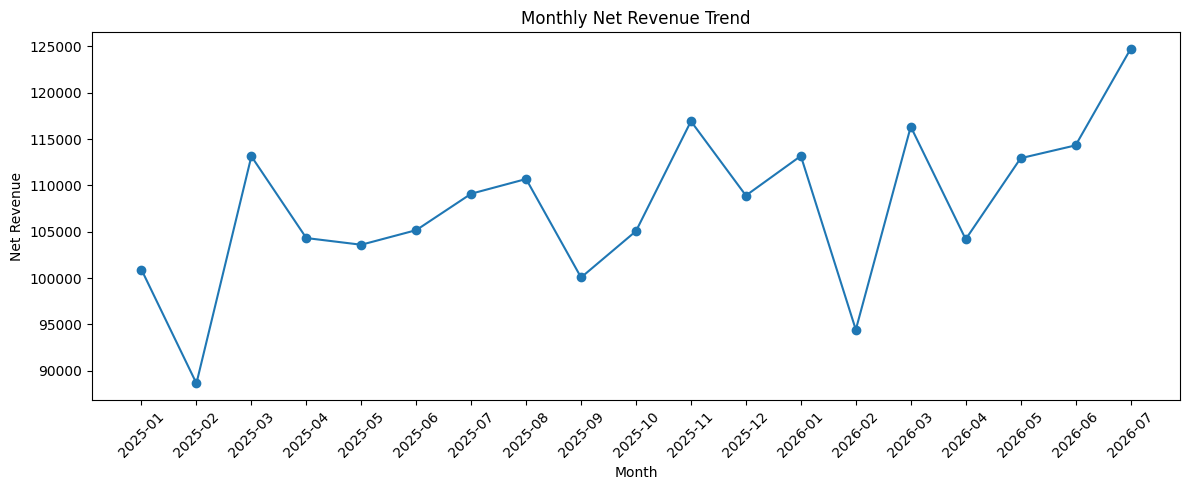

In [111]:
import matplotlib.pyplot as plt

monthly_revenue["year_month"] = (
    monthly_revenue["year"].astype(str)
    + "-"
    + monthly_revenue["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue["year_month"],
    monthly_revenue["net_revenue"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.title("Monthly Net Revenue Trend")
plt.tight_layout()
plt.show()

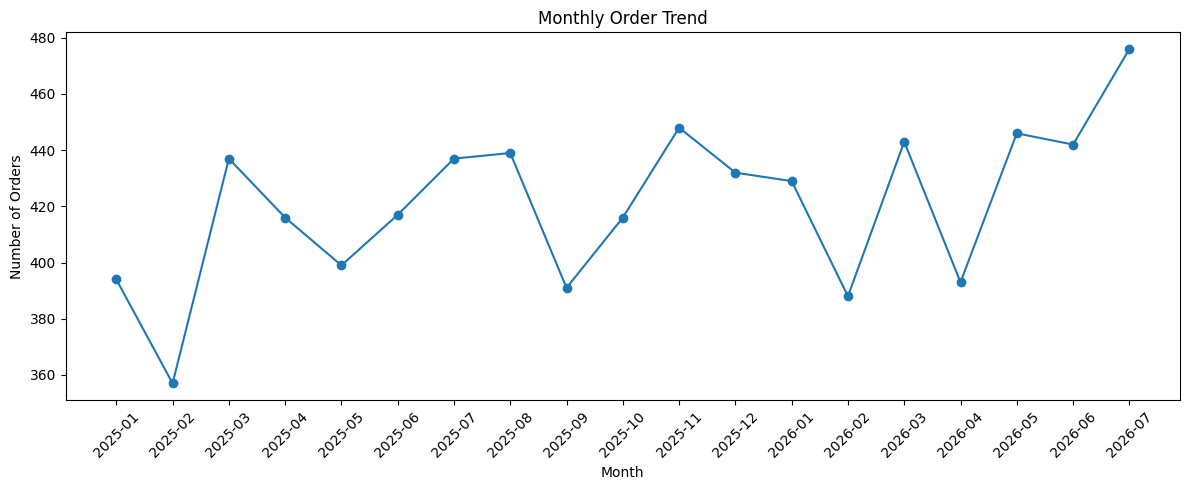

In [112]:
monthly_orders = (
    clean_df.groupby(["year", "month"])["order_id"]
    .nunique()
    .reset_index(name="orders")
)

monthly_orders["year_month"] = (
    monthly_orders["year"].astype(str)
    + "-"
    + monthly_orders["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders["year_month"],
    monthly_orders["orders"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Order Trend")
plt.tight_layout()
plt.show()

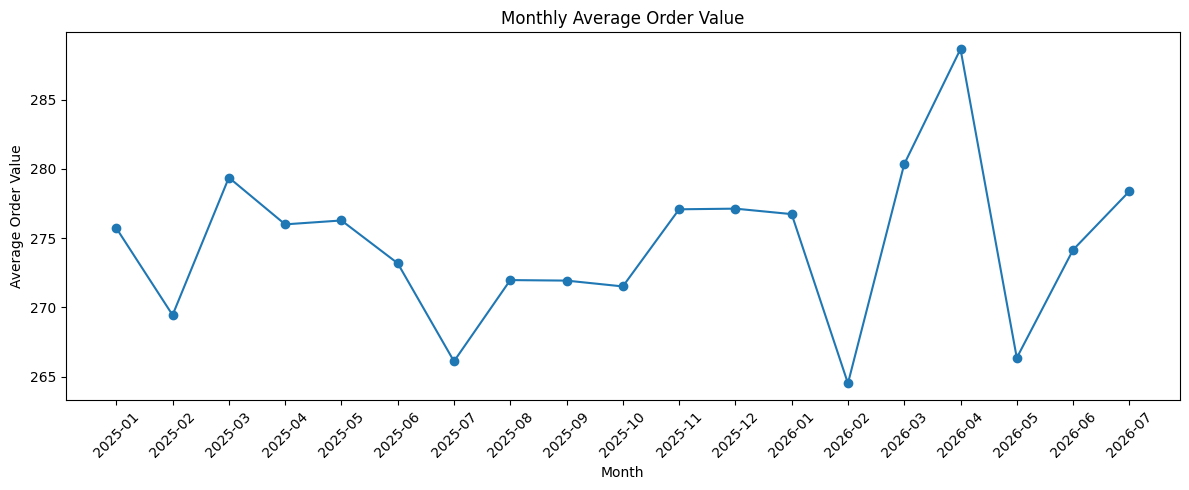

In [113]:
monthly_aov = (
    clean_df.groupby(["year", "month"])["net_revenue"]
    .mean()
    .reset_index(name="aov")
)

monthly_aov["year_month"] = (
    monthly_aov["year"].astype(str)
    + "-"
    + monthly_aov["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_aov["year_month"],
    monthly_aov["aov"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.title("Monthly Average Order Value")
plt.tight_layout()
plt.show()

###finding ยอดขาย
รายได้สูงสุดอยู่ที่ เดือน กค 2026 มาจากที่คนซื้อเพิ่มขึ้น แต่มูลค่าเฉลี่ยต่อ order ยังคงเท่าเดิมเกือบทุกเดือน

### insight ยอดขาย
จำนวน order เป็นปัจจัยสำคัญที่ทำให้รายได้ต่อเดือนสูงขึ้น

##รายได้ต่อเมือง

In [114]:
city_revenue = (
    clean_df.groupby("city")["net_revenue"]
    .sum()
    .sort_values(ascending=False)
)

city_revenue

,net_revenue
city,
Bangkok,856300.56
Chiang Mai,324354.10
Phuket,234047.23
Chonburi,221125.01
Khon Kaen,201097.45
Nakhon Ratchasima,200512.49
Unknown,9317.47


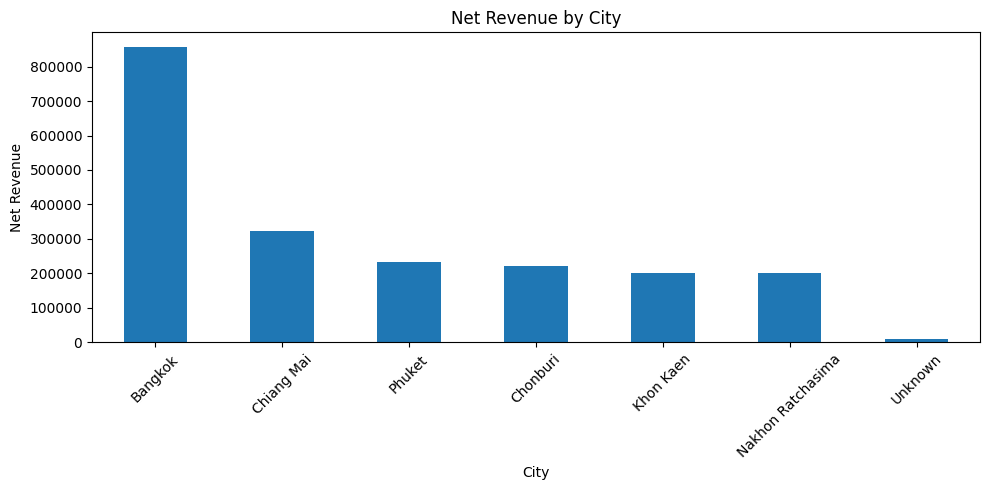

In [115]:
plt.figure(figsize=(10,5))

city_revenue.plot(kind="bar")

plt.xlabel("City")
plt.ylabel("Net Revenue")
plt.title("Net Revenue by City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### finding รายได้ต่อเมือง
Bangkok มีรายได้สูงสุด  ประมาณ 850,000 บาท chiang mai ประมาณ 320,000 บาท phuket ประมาณ 230,000 บาท

###insight รายได้ต่อเมือง
เสี่ยงรายได้กระจุกตัวอยู่ที่ Bangkok เพราะรายได้สูงเกินจากเมืองอื่นๆมากเกินไป

## รายได้ต่อ category

In [116]:
category_revenue = (
    clean_df.groupby("restaurant_category")["net_revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

,net_revenue
restaurant_category,
Japanese,385892.86
Thai,374183.14
Fast Food,356573.50
Chinese,241396.50
Korean,240039.25
Cafe & Bakery,200025.59
Healthy,145546.33
Dessert,93608.41
Unknown,9488.73


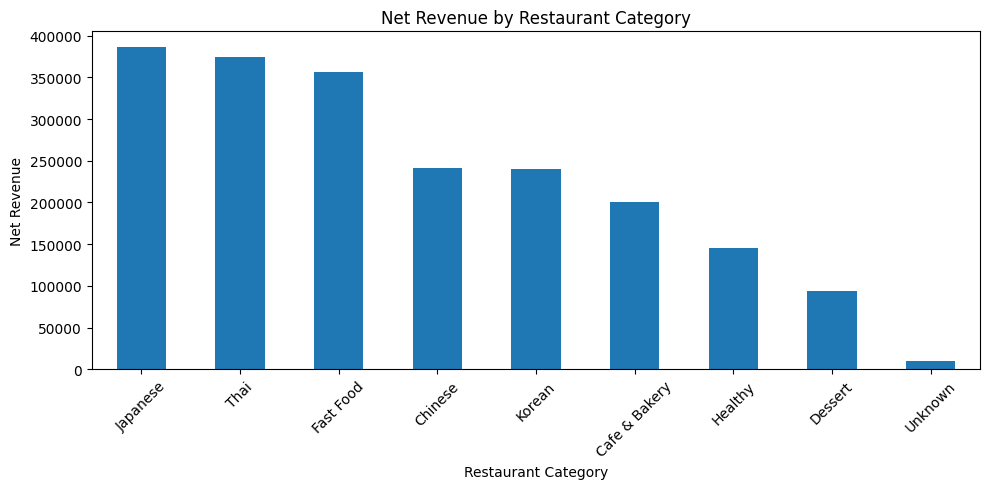

In [117]:
plt.figure(figsize=(10,5))

category_revenue.plot(kind="bar")

plt.xlabel("Restaurant Category")
plt.ylabel("Net Revenue")
plt.title("Net Revenue by Restaurant Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###finding cate
ร้านอาหารญี่ปุ่น สร้างรายได้สูงสุดประมาณ387,000 บาท
รายได้ต่ำสุดอยู่ที่ ของหวาน ประมาณ 93,608.41

### insight cate
รายได้กระจุกอยู่ที่ 3 หมวดหลัก คือ Japanese, Thai และ Fast Food

## order

In [118]:
category_orders = (
    clean_df.groupby("restaurant_category")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

category_orders

,order_id
restaurant_category,
Thai,1731
Fast Food,1470
Japanese,1114
Cafe & Bakery,1033
Chinese,818
Korean,729
Healthy,553
Dessert,517
Unknown,35


In [119]:
category_aov = (
    clean_df.groupby("restaurant_category")["net_revenue"]
    .mean()
    .sort_values(ascending=False)
)

category_aov

,net_revenue
restaurant_category,
Japanese,368.570067
Korean,353.518778
Chinese,313.501948
Healthy,281.520948
Unknown,279.080294
Fast Food,262.572533
Thai,233.718389
Cafe & Bakery,207.710893
Dessert,192.214394


###finding order
ร้านอาหารไทยมี order เยอะสุดที่ 1,731  แต่ aov เพียง 233.72 บาท โดยร้านอาหารญี่ปุ่น มี aov ที่สูงกว่าถึง 368.57 บาท แต่ order เพียง 1,114 order และสร้างรายได้ๆสูงสุด

### insight order
รายได้สูงของร้านอาหารญี่ปุ่น เกิดจาก ราคาต่อorderที่สูง ส่วนร้านอาหารไทยนั้น เป็นหมวดหมู่ที่มาความต้องการสูง และราคาต่อ order ต่ำกว่า


In [120]:
#จาก table นี้
category_summary = (
    clean_df[clean_df["net_revenue"].notna()]
    .groupby("restaurant_category")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("net_revenue", "sum"),
        aov=("net_revenue", "mean")
    )
    .sort_values("revenue", ascending=False)
)

category_summary

,orders,revenue,aov
restaurant_category,,,
Japanese,1047,385892.86,368.570067
Thai,1601,374183.14,233.718389
Fast Food,1358,356573.50,262.572533
Chinese,770,241396.50,313.501948
Korean,679,240039.25,353.518778
Cafe & Bakery,963,200025.59,207.710893
Healthy,517,145546.33,281.520948
Dessert,487,93608.41,192.214394
Unknown,34,9488.73,279.080294


##Average Delivery Time

In [121]:
traffic_delivery = (
    clean_df.groupby("traffic_level")["delivery_time_min"]
    .mean()
    .sort_values(ascending=False)
)

traffic_delivery

,delivery_time_min
traffic_level,
Severe,49.296154
High,39.033825
Unknown,32.325000
Medium,31.832953
Low,26.745500


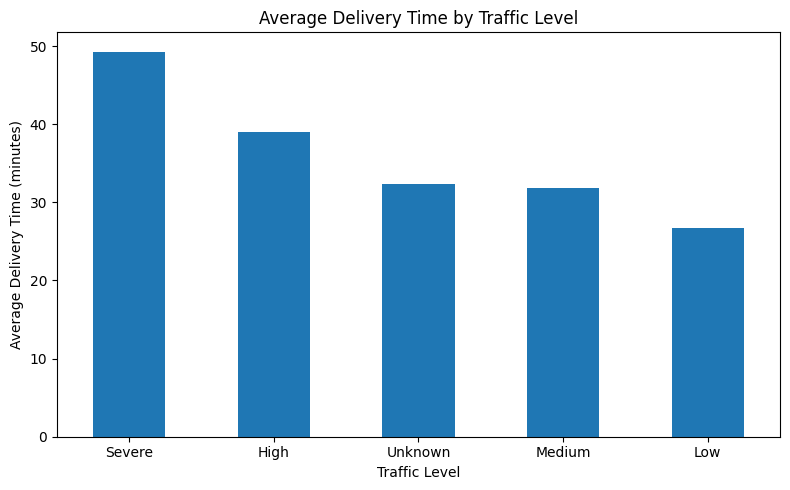

In [122]:
plt.figure(figsize=(8,5))

traffic_delivery.plot(kind="bar")

plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Traffic Level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###finding by traffic
ระดับ traffie ที่เพิ่มขึ้น ทำให้เวลาส่งเฉลี่ยมากขึ้น โดยเวลาส่งเฉลี่ยของ ระดับ Severe อยู่ที่ประมาณ 49 นาที และต่ำสุดที่ประมาณ 27 นาที

###insight by traffic
ปัญหาเกิดจากความล่าช้าของการส่งที่เกิดจากการจราจรที่หนาแน่นและการส่งช้าไม่ได้เกิดจากร้านอาหารเพียงอย่างเดียว

In [123]:
weather_delivery = (
    clean_df.groupby("weather")["delivery_time_min"]
    .mean()
    .sort_values(ascending=False)
)

weather_delivery

,delivery_time_min
weather,
Heavy Rain,47.574713
Rain,39.610409
Unknown,34.500000
Cloudy,33.130258
Clear,31.899360


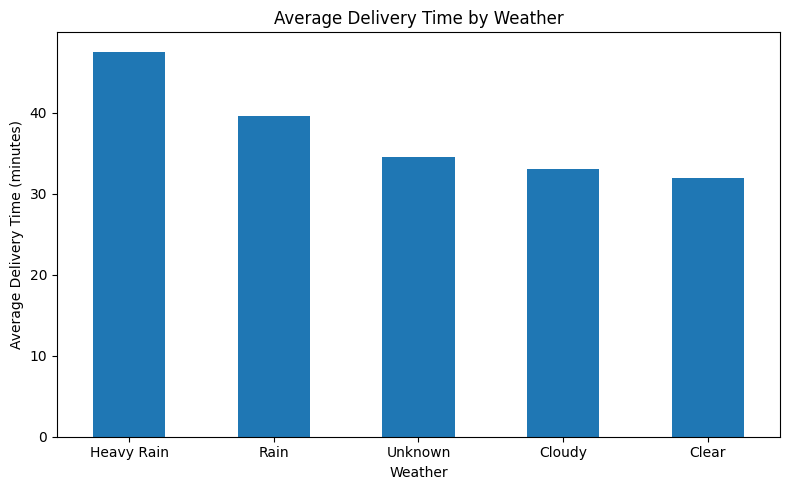

In [124]:
plt.figure(figsize=(8,5))

weather_delivery.plot(kind="bar")

plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Weather")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### finding by weather
ฝนตกหนักทำให้ การส่งอยู่ที่ประมาณ 47-48 นาที
ขณะที่สภาพอากาศปกติ อยู่ประมาณที่ 32 นาที

### insight by weather
สภาพอากาศแย่ลงทำให้เวลาส่งอาหารนานขึ้น

##Customer Experience


In [125]:
rating_delivery = (
    clean_df.groupby(
        "delivery_group",
        observed=False
    )["customer_rating"]
    .mean()
)

rating_delivery

,customer_rating
delivery_group,
0-20,4.932403
21-30,4.939573
31-40,4.842851
41-50,4.606419
51-60,4.287356
60+,3.770161


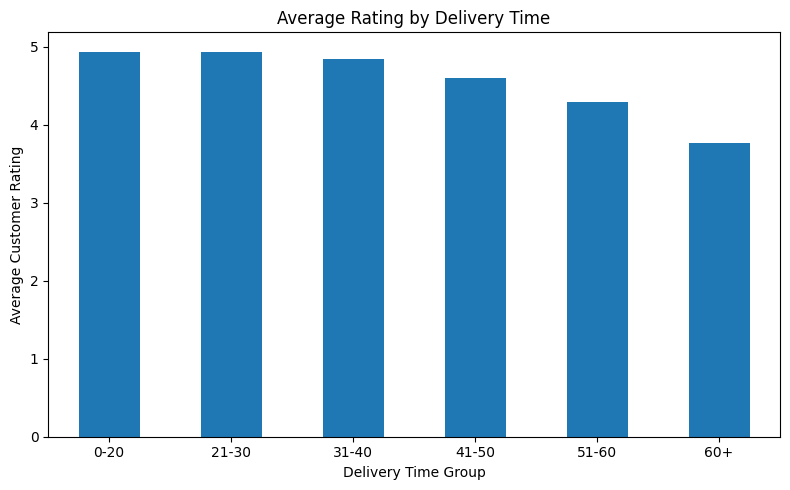

In [126]:
plt.figure(figsize=(8,5))

rating_delivery.plot(kind="bar")

plt.xlabel("Delivery Time Group")
plt.ylabel("Average Customer Rating")
plt.title("Average Rating by Delivery Time")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###finding
คะแนนเฉลี่ยของลูกค้า ลดลงตามเวลาการส่งที่เพิ่มขึ้น โดย 0-20 นาที ได้คะแนน reviewเฉลี่ยที่ 4.9 ดาว
ส่วน 60 นาทีขึ้นไปได้คะแนนเฉลี่ยอยู่ที่ 3.7 ดาว

### insight
ระยะเวลาการส่งมีผลเชิงลบต่อ คะแนนรีวิว  


##Marketing / Campaign Performance

In [127]:
promo_summary = (
    clean_df[clean_df["promo_code"] != "No Promo"]
    .groupby("promo_code")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("net_revenue", "sum"),
        aov=("net_revenue", "mean"),
        total_discount=("discount_amount", "sum")
    )
    .sort_values("revenue", ascending=False)
)

promo_summary

,orders,revenue,aov,total_discount
promo_code,,,,
PAYDAY,796,194156.86,263.800082,20404.09
WEEKEND,609,154432.64,268.112222,15916.08
WELCOME50,634,147688.84,247.800067,26534.52
FREESHIP,639,146373.64,250.211350,0.00
SONGKRAN,520,127614.47,264.760311,13338.79
LUNCH20,498,124101.18,269.199957,8968.30
NEWYEAR,486,123810.55,275.134556,13089.99
Unknown Promo,31,6560.79,252.338077,752.69


###finding
PAYDAY สร้าง Revenue สูงที่สุดประมาณ 194,157 บาท และมี Orders สูงที่สุด 796 Orders ขณะที่ NEWYEAR มี AOV สูงที่สุดประมาณ 275.13 บาท/Order ส่วน WELCOME50 ใช้ส่วนลดรวมสูงที่สุดประมาณ 26,535 บาท แต่ Revenue อยู่เพียงอันดับ 3

###insight


- PAYDAY = Volume driver ดึง Orders และ Revenue ได้สูงสุด
- NEWYEAR = High-value driver ลูกค้าที่ใช้โปรนี้ใช้จ่ายต่อ Order สูงที่สุด
- WELCOME50 = Cost-heavy promo ใช้ส่วนลดมากที่สุด แต่ Revenue/AOV ไม่ได้สูงตาม
- LUNCH20 น่าสนใจมาก เพราะ AOV สูงถึง ~269.20 บาท แต่ใช้ส่วนลดรวมเพียง ~8,968 บาท